/tmp/ipykernel_653/3828171093.py:41: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


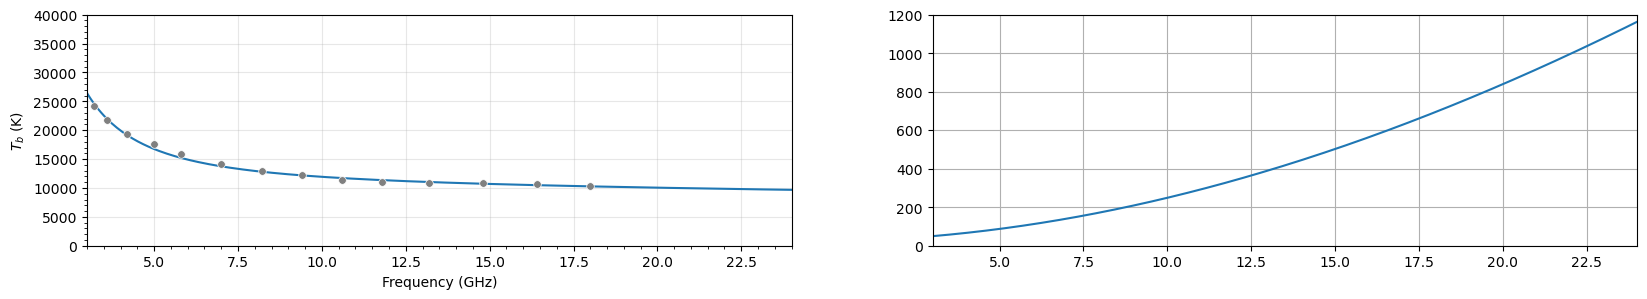

In [2]:
import astropy.constants as const
import astropy.units as u
from srhimages.helpers.zirin_tb import SRHQSunTb

import matplotlib.pyplot as plt


def whole_sun_sfu(freq_ghz):
    f = freq_ghz * 1e9 * u.hertz # частота в Герцах

    # яркостная температура спокойного Солнца на нужной частоте
    # Основывается на кривой Зирина из статьи
    Tb = SRHQSunTb.get_tb(freq_ghz) * u.Kelvin

    sun_angle = 6.794 * 1e-5 # Видимый телесный угол Солнца (в среднем), стерадианы.
    # взял просто в поиске

    # Спектральная плотность потока излучения от Солнца в единицах СИ
    # Используется приближение Рэлея-Джинса, в радиодиапазоне можно применять
    energy = 2 * const.k_B * Tb * (f / const.c)**2 * sun_angle

    # 1 SFU равен этому числу в единицах СИ
    sfu = 1e-22 * u.watt * u.meter**-2 * u.hertz**-1

    # .si - сокращение числителя и знаменателя единиц измерения до единиц СИ
    # если в формуле всё правильно, то должна получиться безразмерная величина
    return (energy / sfu).si

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 3))

SRHQSunTb.plot(ax=ax1)

sfu_list = [whole_sun_sfu(f) for f in SRHQSunTb.freq_list]
ax2.plot(SRHQSunTb.freq_list, sfu_list)
ax1.set_xlim(3, 24)
ax2.set_xlim(3, 24)

ax1.set_ylim(0, 40000)
ax2.set_ylim(0, 1200)
ax2.grid(True)
fig.show()